**Figure 5: Expression epistasis is detected exclusively by track-based models.** **(a)** Distance-controlled adjusted mean difference in $R_\text{singles}$ between 1,451 statistically identified epistatic eQTL pairs (Yang et al.) and two control sets: LD-correlated pairs matched by R² > 0.2 from TopLD (dark bars) and GTEx distance-matched null pairs (light bars). Models sorted by effect size. Borzoi (z = 55.9) and AlphaGenome (z = 19.3) show strong signal against LD controls; no embedding model achieves z > 2. Blue = significant positive, terracotta = significant negative, gray = not significant. P-values derived from z-scores via normal approximation. **(b)** Raw $R_\text{singles}$ distributions for Borzoi (top, strong separation between eQTL and control) and HyenaDNA (bottom, overlapping distributions), illustrating the architectural divide. Dashed lines indicate group means. **(c)** Within-distance-bin mean difference (Δ $R_\text{singles}$) as a function of genomic distance for four representative models, showing that Borzoi's signal is sustained across the full 100 bp – 20 kb range while embedding models remain near zero.

**Supplementary panels** (below): eQTL vs 1kGP single-mutation WT distance ratio per model.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm as _norm
import pyarrow.dataset as ds

# ── Configuration via paper_data_config ──
sys.path.insert(0, str(Path("..").resolve()))
from paper_data_config import EPISTASIS_PAPER_ROOT

PARQUET_DIR = EPISTASIS_PAPER_ROOT / "combined_parquets" / "new_embeddings"
PAIRS_TSV = EPISTASIS_PAPER_ROOT / "data" / "all_pairs_combined.tsv"
OUT_DIR = EPISTASIS_PAPER_ROOT / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILES = {
    "AlphaGenome":   "epistasis_metrics_alphagenome_combined.parquet",
    "Borzoi":        "epistasis_metrics_borzoi_combined.parquet",
    "RiNALMo":       "epistasis_metrics_rinalmo_combined.parquet",
    "HyenaDNA":      "epistasis_metrics_hyenadna_combined.parquet",
    "Caduceus":      "epistasis_metrics_caduceus_combined.parquet",
    "MutBERT":       "epistasis_metrics_mutbert_combined.parquet",
    "NT-500M":       "epistasis_metrics_nt500_multi_combined.parquet",
    "NT-250M":       "epistasis_metrics_nt250_multi_combined.parquet",
    "NT-100M":       "epistasis_metrics_nt100_multi_combined.parquet",
    "NT-50M":        "epistasis_metrics_nt50_multi_combined.parquet",
    "NT-50M-3mer":   "epistasis_metrics_nt50_3mer_combined.parquet",
    "NT-2.5B":       "epistasis_metrics_nt2500_multi_combined.parquet",
    "NT-2.5B-1kGP":  "epistasis_metrics_nt2500_okgp_combined.parquet",
    "NT-500M-ref":   "epistasis_metrics_nt500_ref_combined.parquet",
    "DNABERT":       "epistasis_metrics_dnabert_combined.parquet",
    "SpeciesLM":     "epistasis_metrics_specieslm_combined.parquet",
    "ConvNova":      "epistasis_metrics_convnova_combined.parquet",
    "Evo2":      "epistasis_metrics_evo2_combined.parquet",

}

METRIC = "epi_R_singles"
DIST_RANGE = (100, 20_000)  # bp
N_PERM = 500
N_BINS = 1000
SEED = 0


## Utility functions

In [57]:
def load_model(model_key, sources=None, columns=None):
    """Load one model's parquet, filter by source, deduplicate."""
    fp = PARQUET_DIR / MODEL_FILES[model_key]
    if not fp.exists():
        return None
    dataset = ds.dataset(fp)
    filt = ds.field("source").isin(sources) if sources else None
    table = dataset.to_table(filter=filt, columns=columns)
    df = table.to_pandas()
    del table
    df = df.drop_duplicates(subset=["source", "epistasis_id"], keep="first")
    return df.reset_index(drop=True)


def parse_dist(eid):
    """Extract genomic distance in bp from epistasis_id string.
    Format: GENE:chr:pos:ref:alt:label|GENE:chr:pos:ref:alt:label
    """
    parts = eid.split("|")
    p1 = int(parts[0].split(":")[2])
    p2 = int(parts[1].split(":")[2])
    return abs(p2 - p1)


def prepare_combined(model_key, true_source, null_source):
    """Load eQTL + control data for a model, parse distance, filter, combine."""
    cols = ["source", "epistasis_id", METRIC]
    true_df = load_model(model_key, sources=[true_source], columns=cols)
    null_df = load_model(model_key, sources=[null_source], columns=cols)
    if true_df is None or null_df is None:
        return None, None, None

    true_df["distance"] = true_df["epistasis_id"].apply(parse_dist)
    null_df["distance"] = null_df["epistasis_id"].apply(parse_dist)

    for df in (true_df, null_df):
        df.dropna(subset=[METRIC, "distance"], inplace=True)
        mask = (df.distance >= DIST_RANGE[0]) & (df.distance < DIST_RANGE[1])
        df.drop(df.index[~mask], inplace=True)

    true_sub = true_df[[METRIC, "distance"]].assign(is_true=1)
    null_sub = null_df[[METRIC, "distance"]].assign(is_true=0)
    combined = pd.concat([true_sub, null_sub], ignore_index=True).dropna()
    return combined, true_df, null_df


    

## Distance-controlled permutation test

The key statistical method: within each distance quantile bin, shuffle eQTL/control labels
and recompute the mean difference. This removes the distance confound (epistasis metrics
correlate with genomic distance, so a naive comparison would be biased).

The within-bin mean difference is computed by residualizing against bin means, then
comparing group residuals — equivalent to averaging within-bin diffs but numerically cleaner.

In [58]:
def _withinbin_mean_diff(df, val_col, group_col, bin_col):
    """Compute group mean difference after residualizing against bin means."""
    d = df[[val_col, group_col, bin_col]].dropna().copy()
    d["resid"] = d[val_col] - d.groupby(bin_col, observed=True)[val_col].transform("mean")
    real = d.loc[d[group_col] == 1, "resid"].to_numpy()
    rand = d.loc[d[group_col] == 0, "resid"].to_numpy()
    return float(np.mean(real) - np.mean(rand))


def _permute_within_bins(labels, bins, rng):
    """Shuffle labels independently within each distance bin."""
    out = labels.copy()
    s = pd.Series(bins).astype("category")
    for _, idx in s.groupby(s, observed=True).groups.items():
        idx = np.asarray(list(idx))
        out[idx] = labels[idx][rng.permutation(len(idx))]
    return out


def compute_eqtl_stats(true_source, null_source):
    """Run distance-controlled permutation test for all models.

    Returns DataFrame with: model, n_real, n_rand, adj_mean_diff, z_score, perm_p
    """
    rng = np.random.default_rng(SEED)
    rows = []

    for model_key in MODEL_FILES:
        print(f"  {model_key}...", end=" ", flush=True)

        combined, true_df, null_df = prepare_combined(model_key, true_source, null_source)
        if combined is None:
            print("skip (missing file)")
            continue

        real = true_df[METRIC].values
        rand = null_df[METRIC].values
        real, rand = real[np.isfinite(real)], rand[np.isfinite(rand)]

        if len(real) < 50 or len(rand) < 50:
            print(f"skip (n_real={len(real)}, n_rand={len(rand)})")
            continue

        combined["d_bin"] = pd.qcut(combined["distance"], q=N_BINS, duplicates="drop")
        obs = _withinbin_mean_diff(combined, METRIC, "is_true", "d_bin")

        labels = combined["is_true"].to_numpy()
        bins = combined["d_bin"].to_numpy()
        null_dist = np.empty(N_PERM)
        for i in range(N_PERM):
            perm_lab = _permute_within_bins(labels, bins, rng)
            tmp = combined.copy()
            tmp["is_true"] = perm_lab
            null_dist[i] = _withinbin_mean_diff(tmp, METRIC, "is_true", "d_bin")

        null_dist = null_dist[np.isfinite(null_dist)]
        z = float((obs - np.mean(null_dist)) / (np.std(null_dist) + 1e-12))
        perm_p = float((np.sum(null_dist >= obs) + 1) / (len(null_dist) + 1))

        rows.append({
            "model": model_key, "n_real": len(real), "n_rand": len(rand),
            "adj_mean_diff": obs, "z_score": z, "perm_p": perm_p,
        })
        print(f"Δ={obs:.4f}, z={z:.1f}")

        del combined, true_df, null_df

    stats = pd.DataFrame(rows).sort_values("adj_mean_diff", ascending=False).reset_index(drop=True)
    return stats

## Compute stats for both control sets

This takes a few minutes (17 models × 500 permutations × 2 control sets).

In [43]:
print("=== eQTL vs topLD correlated ===")
topld_stats = compute_eqtl_stats("yang_evqtl", "correlated_eqtl")

print("\n=== eQTL vs GTEx matched null ===")
gtex_stats = compute_eqtl_stats("yang_evqtl", "gtex_matched_null")

# Sort both by topLD effect size
model_order = topld_stats["model"].tolist()
gtex_stats = gtex_stats.set_index("model").loc[model_order].reset_index()
n = len(model_order)

display(topld_stats)
display(gtex_stats)



=== eQTL vs topLD correlated ===
  AlphaGenome... Δ=0.0547, z=19.3
  Borzoi... Δ=0.0950, z=55.9
  RiNALMo... Δ=0.0006, z=0.4
  HyenaDNA... Δ=-0.0003, z=-4.7
  Caduceus... Δ=-0.0004, z=-2.7
  MutBERT... Δ=-0.0006, z=-1.3
  NT-500M... Δ=0.0080, z=7.9
  NT-250M... Δ=-0.0004, z=-0.7
  NT-100M... Δ=0.0025, z=3.5
  NT-50M... Δ=-0.0012, z=-3.2
  NT-50M-3mer... Δ=-0.0010, z=-3.4
  NT-2.5B... Δ=0.0010, z=1.0
  NT-2.5B-1kGP... Δ=-0.0017, z=-5.2
  NT-500M-ref... Δ=-0.0014, z=-5.2
  DNABERT... Δ=-0.0160, z=-3.6
  SpeciesLM... Δ=-0.0015, z=-4.0
  ConvNova... Δ=-0.0000, z=-2.2
  Evo2... Δ=0.0293, z=6.3

=== eQTL vs GTEx matched null ===
  AlphaGenome... Δ=0.0111, z=2.9
  Borzoi... Δ=0.0232, z=8.9
  RiNALMo... Δ=-0.0001, z=0.0
  HyenaDNA... Δ=-0.0000, z=-0.7
  Caduceus... Δ=0.0001, z=0.5
  MutBERT... Δ=-0.0017, z=-3.1
  NT-500M... Δ=-0.0042, z=-2.7
  NT-250M... Δ=-0.0030, z=-4.8
  NT-100M... Δ=-0.0022, z=-2.2
  NT-50M... Δ=-0.0008, z=-2.6
  NT-50M-3mer... Δ=-0.0006, z=-3.9
  NT-2.5B... Δ=-0.0022, z=-

,model,n_real,n_rand,adj_mean_diff,z_score,perm_p
0,Borzoi,1420,26438,0.094977,55.902149,0.001996
1,AlphaGenome,1420,26528,0.054653,19.272183,0.001996
2,Evo2,1420,26528,0.029260,6.295491,0.001996
3,NT-500M,1420,26528,0.007963,7.867016,0.001996
4,NT-100M,1420,26528,0.002473,3.520752,0.003992
5,NT-2.5B,1420,26528,0.001030,0.974637,0.159681
6,RiNALMo,1420,26528,0.000605,0.363576,0.363273
7,ConvNova,1420,26528,-0.000019,-2.217059,1.000000
8,HyenaDNA,1420,26521,-0.000267,-4.680513,1.000000
9,NT-250M,1420,26528,-0.000401,-0.728708,0.778443


,model,n_real,n_rand,adj_mean_diff,z_score,perm_p
0,Borzoi,1420,5786,0.023159,8.933746,0.001996
1,AlphaGenome,1420,5786,0.011117,2.947003,0.003992
2,Evo2,1420,5786,0.017924,3.549307,0.001996
3,NT-500M,1420,5786,-0.004201,-2.707255,0.998004
4,NT-100M,1420,5786,-0.002238,-2.242869,0.992016
5,NT-2.5B,1420,5786,-0.002176,-1.646814,0.958084
6,RiNALMo,1420,5786,-0.000109,0.003202,0.481038
7,ConvNova,1420,5786,-0.000020,-4.589360,1.000000
8,HyenaDNA,1420,5786,-0.000042,-0.687830,0.748503
9,NT-250M,1420,5786,-0.002982,-4.840132,1.000000


## Figure: 3-panel eQTL comparison

In [59]:
# ── Style constants ──
GRAY_LIGHT  = "#E8E8E8"
GRAY_MID    = "#999999"
GRAY_DARK   = "#333333"
COL_BLUE    = "#4A7FB5"
COL_TERRA   = "#CB6A49"
COL_NONSIG  = "#CCCCCC"
COL_BLUE_L  = "#8BB8DB"
COL_TERRA_L = "#DDA088"
COL_NONSIG_L = "#DDDDDD"
MM = 1 / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 7, "axes.linewidth": 0.4, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6.5,
    "xtick.major.size": 2, "ytick.major.size": 0,
    "xtick.major.width": 0.4, "ytick.major.width": 0,
    "xtick.major.pad": 2, "ytick.major.pad": 2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.unicode_minus": False,
})


def setup_ax(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_linewidth(0.4)
        ax.spines[sp].set_color(GRAY_MID)
    ax.tick_params(colors=GRAY_DARK, which="both")


def panel_label(ax, letter, x=-0.12):
    ax.text(x, 1.03, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right", color="black")


def _format_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ""
    if p >= 0.01:
        return f"{p:.2f}"
    return f"{p:.1e}".replace("e", "E").replace("E-0", "E-").replace("E+0", "E+")


def _p_from_z(z):
    """Two-sided p from z-score; handles underflow via logsf."""
    p = float(2 * _norm.sf(abs(z)))
    if p > 0:
        return p, _format_p(p)
    log10_p = float(_norm.logsf(abs(z)) / 2.302585 + 0.301)
    return 0.0, f"<1E{int(log10_p)}"


def _bar_color(p, v, dark=True):
    if p < 0.05 and v > 0:
        return COL_BLUE if dark else COL_BLUE_L
    elif p < 0.05 and v <= 0:
        return COL_TERRA if dark else COL_TERRA_L
    return COL_NONSIG if dark else COL_NONSIG_L

    

Saved to /Users/nicolaslynn/Downloads/output_figs


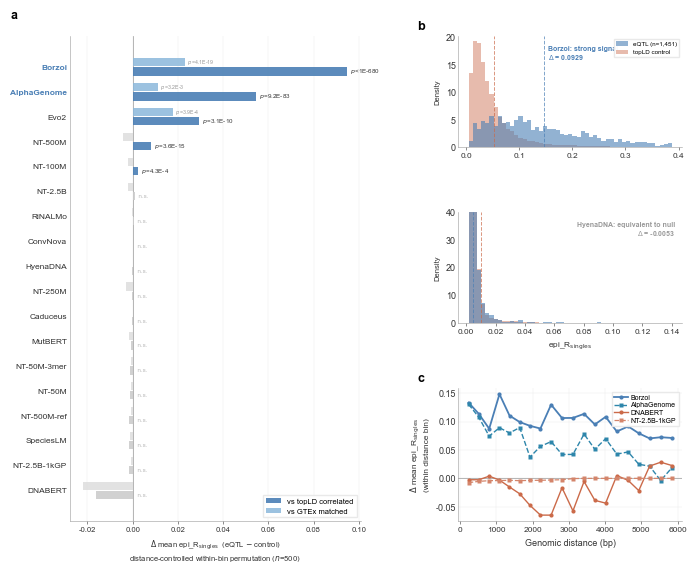

In [60]:
# ── Build figure ──
fig = plt.figure(figsize=(183 * MM, 140 * MM))
gs_outer = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.38,
                            left=0.12, right=0.97, top=0.96, bottom=0.08)
ax_bar = fig.add_subplot(gs_outer[0])
gs_right = gs_outer[1].subgridspec(3, 1, height_ratios=[1, 1, 1.2], hspace=0.55)
ax_dist_top = fig.add_subplot(gs_right[0])
ax_dist_bot = fig.add_subplot(gs_right[1])
ax_bin = fig.add_subplot(gs_right[2])
for ax in (ax_bar, ax_dist_top, ax_dist_bot, ax_bin):
    setup_ax(ax)

# ═══════════════════════════════════════════════════════════════
# Panel A: Double bar chart with permutation p-values
# ═══════════════════════════════════════════════════════════════
y = np.arange(n)
bar_h = 0.33

topld_vals = topld_stats["adj_mean_diff"].values
gtex_vals  = gtex_stats["adj_mean_diff"].values
topld_p    = topld_stats["perm_p"].values
gtex_p     = gtex_stats["perm_p"].values
topld_z    = topld_stats["z_score"].values
gtex_z     = gtex_stats["z_score"].values

topld_colors = [_bar_color(topld_p[i], topld_vals[i], True) for i in range(n)]
gtex_colors  = [_bar_color(gtex_p[i], gtex_vals[i], False) for i in range(n)]

ax_bar.barh(y + bar_h/2 + 0.02, topld_vals, height=bar_h, color=topld_colors,
            edgecolor="none", alpha=0.90, zorder=2)
ax_bar.barh(y - bar_h/2 - 0.02, gtex_vals, height=bar_h, color=gtex_colors,
            edgecolor="none", alpha=0.85, zorder=2)
ax_bar.axvline(0, color=GRAY_MID, linewidth=0.5, zorder=1)
ax_bar.tick_params(axis="x", labelsize=5.5)

# P-value annotations
for i in range(n):
    # topLD bar
    v_t, z_t, p_t = topld_vals[i], topld_z[i], topld_p[i]
    _, p_str = _p_from_z(z_t)
    y_t = y[i] + bar_h/2 + 0.02
    if p_t < 0.05:
        label = f"$p${p_str}" if p_str.startswith("<") else f"$p$={p_str}"
        ax_bar.text(v_t, y_t, f"  {label}" if v_t >= 0 else f"{label}  ",
                    ha="left" if v_t >= 0 else "right", va="center",
                    fontsize=4.5, color=GRAY_DARK)
    else:
        ax_bar.text(max(v_t, 0.0005), y_t, "  n.s.",
                    ha="left", va="center", fontsize=4.5, color="#BBBBBB")

    # GTEx bar
    v_g, z_g, p_g = gtex_vals[i], gtex_z[i], gtex_p[i]
    _, p_str_g = _p_from_z(z_g)
    y_g = y[i] - bar_h/2 - 0.02
    if p_g < 0.05:
        label_g = f"$p${p_str_g}" if p_str_g.startswith("<") else f"$p$={p_str_g}"
        ax_bar.text(v_g, y_g, f"  {label_g}" if v_g >= 0 else f"{label_g}  ",
                    ha="left" if v_g >= 0 else "right", va="center",
                    fontsize=3.8, color=GRAY_MID)

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(model_order, fontsize=6)
ax_bar.invert_yaxis()
for i, m in enumerate(model_order):
    if m in ("Borzoi", "AlphaGenome"):
        ax_bar.get_yticklabels()[i].set_fontweight("bold")
        ax_bar.get_yticklabels()[i].set_color(COL_BLUE)

ax_bar.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.set_xlabel(
    r"$\Delta$ mean epi_R$_{\mathrm{singles}}$  (eQTL $-$ control)"
    f"\ndistance-controlled within-bin permutation ($n$={N_PERM})",
    fontsize=5.5, color=GRAY_DARK)

legend_handles = [
    mpatches.Patch(facecolor=COL_BLUE, alpha=0.9, label="vs topLD correlated"),
    mpatches.Patch(facecolor=COL_BLUE_L, alpha=0.85, label="vs GTEx matched"),
]
ax_bar.legend(handles=legend_handles, loc="lower right", fontsize=5.5,
              frameon=True, fancybox=False, edgecolor=GRAY_LIGHT,
              framealpha=0.95, borderpad=0.4)
panel_label(ax_bar, "a", x=-0.18)

# ═══════════════════════════════════════════════════════════════
# Panel B: Distribution histograms (Borzoi vs HyenaDNA)
# ═══════════════════════════════════════════════════════════════
panel_b_configs = [
    ("Borzoi",   ax_dist_top, COL_BLUE, "strong signal"),
    ("HyenaDNA", ax_dist_bot, GRAY_MID, "equivalent to null"),
]
cols_b = ["source", "epistasis_id", METRIC]

for model_key, ax_d, main_col, label_txt in panel_b_configs:
    true_df = load_model(model_key, sources=["yang_evqtl"], columns=cols_b)
    null_df = load_model(model_key, sources=["correlated_eqtl"], columns=cols_b)

    real_v = true_df[METRIC].dropna().values
    null_v = null_df[METRIC].dropna().values
    real_v, null_v = real_v[np.isfinite(real_v)], null_v[np.isfinite(null_v)]

    lo, hi = np.percentile(np.concatenate([real_v, null_v]), [1, 99])
    bins = np.linspace(lo, hi, 50)

    ax_d.hist(real_v, bins=bins, density=True, alpha=0.6, color=COL_BLUE,
              label=f"eQTL (n={len(real_v):,})", zorder=3, linewidth=0)
    ax_d.hist(null_v, bins=bins, density=True, alpha=0.45, color=COL_TERRA,
              label="topLD control", zorder=2, linewidth=0)

    delta = np.mean(real_v) - np.mean(null_v)
    txt_x = 0.40 if model_key == "Borzoi" else 0.97
    txt_ha = "left" if model_key == "Borzoi" else "right"
    ax_d.text(txt_x, 0.92, f"{model_key}: {label_txt}\n$\\Delta$ = {delta:.4f}",
              transform=ax_d.transAxes, fontsize=5, color=main_col,
              fontweight="bold", ha=txt_ha, va="top",
              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    ax_d.axvline(np.mean(real_v), color=COL_BLUE, lw=0.7, ls="--", alpha=0.7, zorder=4)
    ax_d.axvline(np.mean(null_v), color=COL_TERRA, lw=0.7, ls="--", alpha=0.7, zorder=4)
    ax_d.set_ylabel("Density", fontsize=5.5, color=GRAY_DARK)
    ax_d.set_ylim(0, min(ax_d.get_ylim()[1], 40))
    del true_df, null_df

ax_dist_top.legend(fontsize=4.5, loc="upper right", frameon=True, fancybox=False,
                   edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.3)
ax_dist_bot.set_xlabel(r"epi_R$_{\mathrm{singles}}$", fontsize=6, color=GRAY_DARK)
panel_label(ax_dist_top, "b", x=-0.15)

# ═══════════════════════════════════════════════════════════════
# Panel C: Within-bin Δ across genomic distance
# ═══════════════════════════════════════════════════════════════
show_models = {
    "Borzoi":       (COL_BLUE,  "-",  1.3, "o"),
    "AlphaGenome":  ("#2E86AB", "--", 1.0, "s"),
    "DNABERT":      (COL_TERRA, "-",  1.0, "o"),
    "NT-2.5B-1kGP": ("#D4856B", "--", 0.9, "s"),
}

for model_key, (col, ls, lw, mk) in show_models.items():
    combined, _, _ = prepare_combined(model_key, "yang_evqtl", "correlated_eqtl")
    combined["d_bin"] = pd.qcut(combined["distance"], q=20, duplicates="drop")

    bin_means, bin_centers = [], []
    for _, bg in combined.groupby("d_bin", observed=True):
        rv = bg.loc[bg.is_true == 1, METRIC].values
        nv = bg.loc[bg.is_true == 0, METRIC].values
        if len(rv) >= 10 and len(nv) >= 10:
            bin_means.append(np.mean(rv) - np.mean(nv))
            bin_centers.append(bg["distance"].mean())

    ax_bin.plot(bin_centers, bin_means, color=col, linestyle=ls, linewidth=lw,
                marker=mk, markersize=3, markeredgecolor="none",
                label=model_key, zorder=3)
    del combined

ax_bin.axhline(0, color=GRAY_MID, linewidth=0.5, zorder=1)
ax_bin.set_xlabel("Genomic distance (bp)", fontsize=6.5, color=GRAY_DARK)
ax_bin.set_ylabel(r"$\Delta$ mean epi_R$_{\mathrm{singles}}$"
                  "\n(within distance bin)", fontsize=6, color=GRAY_DARK)
ax_bin.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_bin.yaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_bin.set_axisbelow(True)
ax_bin.legend(fontsize=5, loc="upper right", frameon=True, fancybox=False,
              edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.4,
              handletextpad=0.3, labelspacing=0.25)
panel_label(ax_bin, "c", x=-0.15)

# ── Save ──
for ext in (".png", ".pdf"):
    fig.savefig(OUT_DIR / f"fig_eqtl_final{ext}", dpi=600,
                bbox_inches="tight", facecolor="white", edgecolor="none")
print(f"Saved to {OUT_DIR}")
plt.show()




## Supplementary: eQTL single-mutation WT distance vs background

Do eQTL variants perturb model embeddings more than random variants? For each eQTL pair,
we take the **larger** of `len_WT_M1` / `len_WT_M2` (the variant with greater effect on the
embedding — likely the one driving expression change) and compare this distribution to
single-mutation WT distances from `okgp_chr12` (random genomic background).

In [61]:
# ═══════════════════════════════════════════════════════════════════════
# Compute: eQTL vs 1kGP — which has larger single-mutation WT distances?
# For each model: median(max(len_WT) for eQTL) / median(max(len_WT) for 1kGP)
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

eqtl_wt_rows = []

for model_key in MODEL_FILES:
    print(f"  {model_key}...", end=" ", flush=True)

    eqtl_df = load_model(model_key, sources=["yang_evqtl"],
                         columns=["source", "epistasis_id", "len_WT_M1", "len_WT_M2"])
    bg_df = load_model(model_key, sources=["okgp_chr12"],
                       columns=["source", "epistasis_id", "len_WT_M1", "len_WT_M2"])

    if eqtl_df is None or bg_df is None or len(eqtl_df) == 0 or len(bg_df) == 0:
        print("skip")
        continue

    eqtl_max = np.maximum(eqtl_df["len_WT_M1"].values, eqtl_df["len_WT_M2"].values)
    bg_max = np.maximum(bg_df["len_WT_M1"].values, bg_df["len_WT_M2"].values)
    eqtl_max = eqtl_max[np.isfinite(eqtl_max)]
    bg_max = bg_max[np.isfinite(bg_max)]

    if len(eqtl_max) < 20 or len(bg_max) < 20:
        print("skip")
        continue

    ratio = np.median(eqtl_max) / np.median(bg_max)
    # Two-sided test
    _, p_val = mannwhitneyu(eqtl_max, bg_max, alternative="two-sided")

    eqtl_wt_rows.append({
        "model": model_key,
        "ratio": ratio,
        "mwu_p": float(p_val),
        "n_eqtl": len(eqtl_max),
        "n_bg": len(bg_max),
    })
    print(f"ratio={ratio:.2f}, p={p_val:.2e}")
    del eqtl_df, bg_df

eqtl_wt_stats = pd.DataFrame(eqtl_wt_rows).sort_values("ratio", ascending=False).reset_index(drop=True)
display(eqtl_wt_stats)

  AlphaGenome... ratio=0.97, p=1.05e-01
  Borzoi... ratio=1.42, p=8.55e-39
  RiNALMo... ratio=0.19, p=0.00e+00
  HyenaDNA... ratio=0.94, p=3.93e-21
  Caduceus... ratio=0.92, p=3.34e-19
  MutBERT... ratio=0.26, p=0.00e+00
  NT-500M... ratio=0.62, p=3.02e-254
  NT-250M... ratio=0.62, p=0.00e+00
  NT-100M... ratio=0.65, p=3.58e-246
  NT-50M... ratio=0.57, p=0.00e+00
  NT-50M-3mer... ratio=0.91, p=2.06e-25
  NT-2.5B... ratio=0.74, p=6.20e-43
  NT-2.5B-1kGP... ratio=0.89, p=1.48e-62
  NT-500M-ref... ratio=0.84, p=1.01e-69
  DNABERT... ratio=0.43, p=0.00e+00
  SpeciesLM... ratio=0.33, p=0.00e+00
  ConvNova... ratio=0.39, p=0.00e+00
  Evo2... ratio=0.75, p=1.90e-91


,model,ratio,mwu_p,n_eqtl,n_bg
0,Borzoi,1.417645,8.546039e-39,1451,99625
1,AlphaGenome,0.967781,1.053735e-01,1451,100000
2,HyenaDNA,0.935704,3.926691e-21,1451,25375
3,Caduceus,0.919268,3.340444e-19,1451,31369
4,NT-50M-3mer,0.910013,2.060084e-25,1451,100000
5,NT-2.5B-1kGP,0.893179,1.478731e-62,1451,38138
6,NT-500M-ref,0.840135,1.005668e-69,1451,43592
7,Evo2,0.751022,1.903063e-91,1451,100000
8,NT-2.5B,0.742189,6.198840e-43,1451,10000
9,NT-100M,0.645834,3.577253e-246,1451,100000


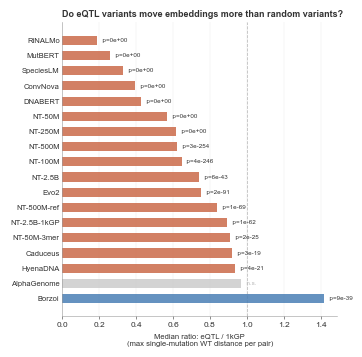

Saved fig_eqtl_wt_distance to /Users/nicolaslynn/Downloads/output_figs


In [62]:
# ═══════════════════════════════════════════════════════════════════════
# Plot: eQTL / 1kGP median ratio of single-mutation WT distance
# ═══════════════════════════════════════════════════════════════════════

wt_sorted = eqtl_wt_stats.sort_values("ratio", ascending=True).reset_index(drop=True)
wt_order = wt_sorted["model"].tolist()
n_wt = len(wt_order)

fig_wt, ax_wt = plt.subplots(figsize=(90 * MM, max(70, 4.5 * n_wt + 16) * MM))
setup_ax(ax_wt)

y_wt = np.arange(n_wt)
ratios = wt_sorted["ratio"].values
p_vals = wt_sorted["mwu_p"].values

bar_colors = []
for r, p in zip(ratios, p_vals):
    if p < 0.05 and r > 1:
        bar_colors.append(COL_BLUE)
    elif p < 0.05 and r <= 1:
        bar_colors.append(COL_TERRA)
    else:
        bar_colors.append(COL_NONSIG)

ax_wt.barh(y_wt, ratios, height=0.6, color=bar_colors,
           edgecolor="none", alpha=0.85, zorder=2)
ax_wt.axvline(1.0, color=GRAY_MID, linewidth=0.6, linestyle="--", alpha=0.6, zorder=1)

for i in range(n_wt):
    p = p_vals[i]
    p_str = f"p={p:.0e}" if p < 0.01 else (f"p={p:.2f}" if p < 0.05 else "n.s.")
    col = GRAY_DARK if p < 0.05 else "#BBBBBB"
    ax_wt.text(ratios[i] + 0.01, y_wt[i], f"  {p_str}",
               ha="left", va="center", fontsize=4.5, color=col)

ax_wt.set_yticks(y_wt)
ax_wt.set_yticklabels(wt_order, fontsize=5.5)
ax_wt.invert_yaxis()
ax_wt.set_xlabel("Median ratio: eQTL / 1kGP\n(max single-mutation WT distance per pair)",
                 fontsize=5.5, color=GRAY_DARK)
ax_wt.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_wt.set_axisbelow(True)

ax_wt.set_title("Do eQTL variants move embeddings more than random variants?",
                fontsize=6.5, color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

for ext in (".png", ".pdf"):
    fig_wt.savefig(OUT_DIR / f"fig_eqtl_wt_distance{ext}", dpi=600,
                   bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_eqtl_wt_distance to {OUT_DIR}")